<a href="https://colab.research.google.com/github/Sebastian1657/SILaboratories/blob/main/SI_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [16]:
training_data = np.load('TF_dataset.npz')
input_size = 2
output_size = 1

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)
])
model.compile(optimizer='sgd', loss='mean_squared_error')
model.fit(training_data['inputs'], training_data['targets'], epochs=10, verbose=1)

Epoch 1/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 904us/step - loss: 0.3713
Epoch 2/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 29s 924us/step - loss: 3.3155e-10
Epoch 3/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 895us/step - loss: 3.2770e-10
Epoch 4/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 30s 949us/step - loss: 3.2743e-10
Epoch 5/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 3.2748e-10
Epoch 6/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 3.2749e-10
Epoch 7/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 36s 990us/step - loss: 3.2754e-10
Epoch 8/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 899us/step - loss: 3.2748e-10
Epoch 9/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 30s 959us/step - loss: 3.2756e-10
Epoch 10/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 3.2759e-10


In [8]:
model.layers[0].get_weights()

[array([[13.],
        [ 7.]], dtype=float32),
 array([-11.999982], dtype=float32)]

In [9]:
model.predict_on_batch(training_data['inputs']).round(1)

array([[ -51.2],
       [-162.5],
       [  84.7],
       ...,
       [ -45. ],
       [  -3.2],
       [ -12.9]], dtype=float32)

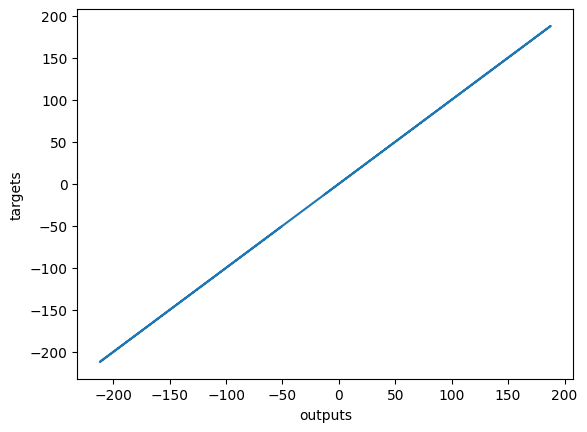

In [11]:
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])),
         np.squeeze(training_data['targets']))
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

In [26]:
#test różnych funkcji optymalizacji

print("SGD:")
model_sgd = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)
])
model_sgd.compile(optimizer='sgd', loss='mean_squared_error')
model_sgd.fit(training_data['inputs'], training_data['targets'], epochs=2, verbose=0)
print("SGD weights:", model_sgd.layers[0].get_weights())
print("\n")

print("SGD with absolute error:")
model_sgd_abs = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)
])
model_sgd_abs.compile(optimizer='sgd', loss='mean_absolute_error')
model_sgd_abs.fit(training_data['inputs'], training_data['targets'], epochs=2, verbose=0)
print("SGD with absolute error weights:", model_sgd_abs.layers[0].get_weights())
print("\n")

print("Adam:")
model_adam = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)
])
model_adam.compile(optimizer='adam', loss='mean_squared_error')
model_adam.fit(training_data['inputs'], training_data['targets'], epochs=2, verbose=0)
print("Adam weights:", model_adam.layers[0].get_weights())

print("Adagrad:")
model_adagrad = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)
])
model_adagrad.compile(optimizer='adagrad', loss='mean_squared_error')
model_adagrad.fit(training_data['inputs'], training_data['targets'], epochs=2, verbose=0)
print("Adagrad weights:", model_adagrad.layers[0].get_weights())

SGD:
SGD weights: [array([[13.],
       [ 7.]], dtype=float32), array([-11.999983], dtype=float32)]


SGD with absolute error:
SGD with absolute error weights: [array([[13.0099  ],
       [ 6.972149]], dtype=float32), array([-11.998478], dtype=float32)]


Adam:
Adam weights: [array([[13.00001 ],
       [ 7.000003]], dtype=float32), array([-12.000021], dtype=float32)]
Adagrad:
Adagrad weights: [array([[-0.9143845],
       [ 0.3284944]], dtype=float32), array([-0.29194534], dtype=float32)]


In [19]:
sigmoid_model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation='sigmoid'),
    tf.keras.layers.Dense(5, activation='sigmoid'),
    tf.keras.layers.Dense(output_size)
])
sigmoid_model.compile(optimizer='sgd', loss='mean_squared_error')
sigmoid_model.fit(training_data['inputs'], training_data['targets'], epochs=5, verbose=1)

Epoch 1/5
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 31s 982us/step - loss: 752.2477
Epoch 2/5
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 30s 949us/step - loss: 564.9153
Epoch 3/5
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 44s 1ms/step - loss: 562.5179
Epoch 4/5
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 30s 946us/step - loss: 559.3068
Epoch 5/5
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step - loss: 560.4066


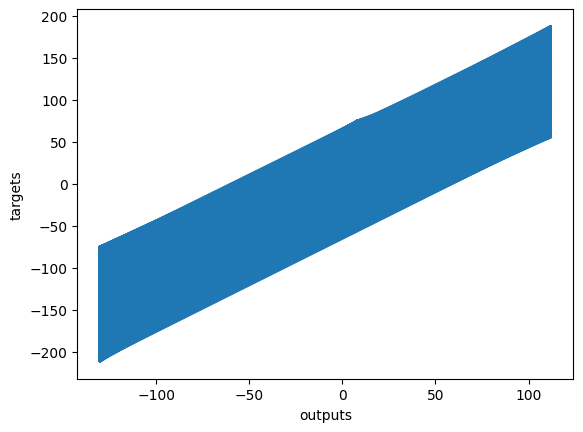

In [25]:
plt.plot(np.squeeze(sigmoid_model.predict_on_batch(training_data['inputs'])),
         np.squeeze(training_data['targets']))
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()